In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Veri setini doğrudan internetten çekiyoruz (Pima Indians Diabetes Dataset)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Kolon isimlerini el ile tanımlıyoruz
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

# İlk 5 satı
print("Veri Seti İlk 5 Satır:")
display(df.head())

Veri Seti İlk 5 Satır:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Mantıken 0 olamayacak kolonlardaki 0 değerlerini NaN ile değiştiriyoruz
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

# NaN değerleri o kolonun medyanı ile dolduruyoruz
df.fillna(df.median(), inplace=True)

# Veriyi özellikler (X) ve hedef değişken (y) olarak ayıralım
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Logistic Regression doğrusal çalıştığı için verileri standartlaştırıyoruz (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# 1. Model: Logistic Regression (Basit/Doğrusal Model)
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# 2. Model: Random Forest Classifier (Karmaşık/Ağaç Tabanlı Model)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Ağaç tabanlı modeller scaling gerektirmez
rf_pred = rf_model.predict(X_test)

# Sonuçları Yazdıralım
print("=== LOGISTIC REGRESSION PERFORMANSI ===")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.4f}")
print(classification_report(y_test, log_pred))

print("\n=== RANDOM FOREST PERFORMANSI ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

=== LOGISTIC REGRESSION PERFORMANSI ===
Accuracy: 0.7078
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


=== RANDOM FOREST PERFORMANSI ===
Accuracy: 0.7792
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



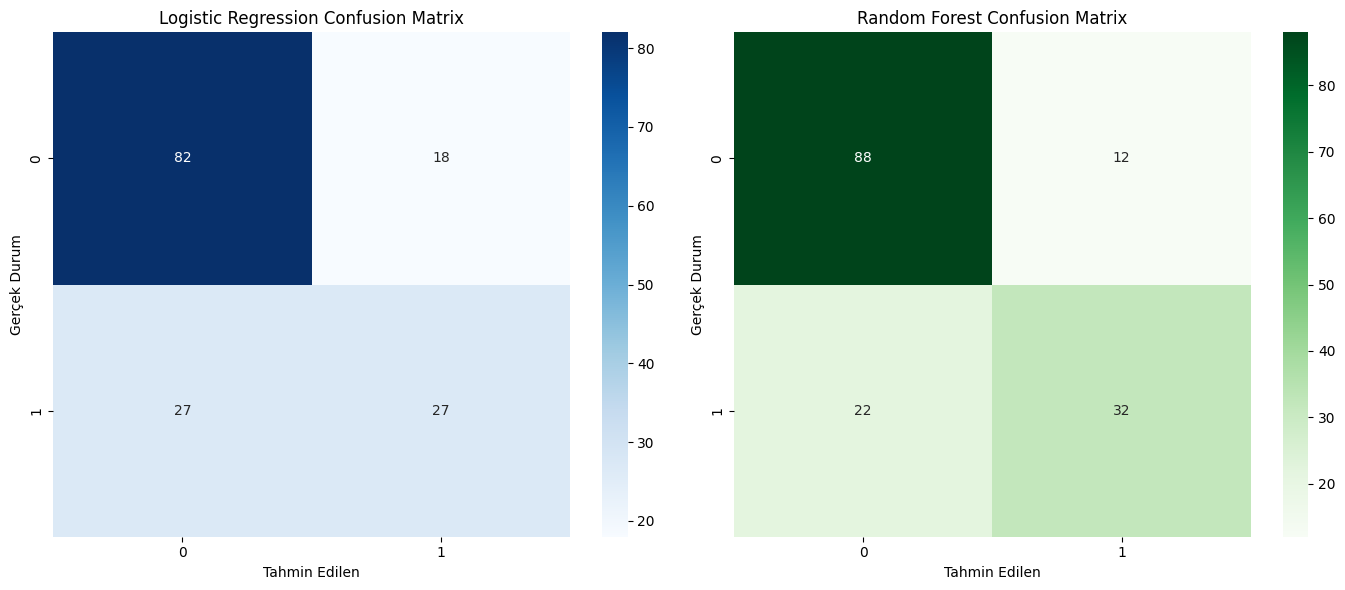

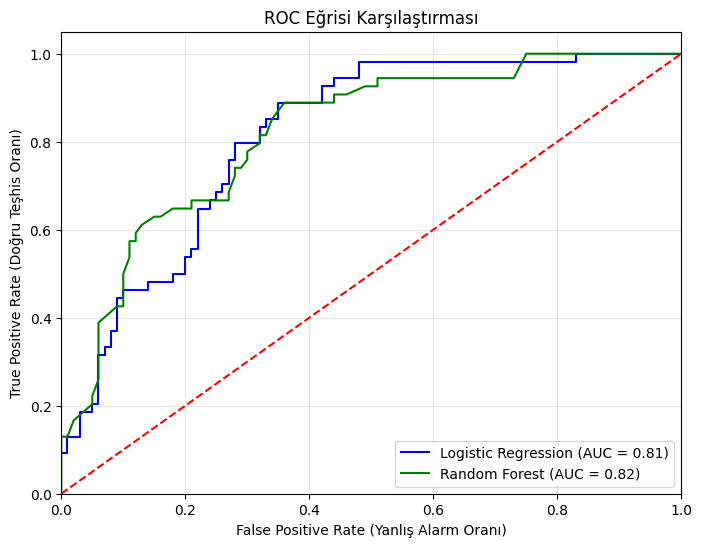

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)

# 1. Grafik: Logistic Regression Confusion Matrix
log_cm = confusion_matrix(y_test, log_pred)
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek Durum')

# 2. Grafik: Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Tahmin Edilen')
axes[1].set_ylabel('Gerçek Durum')

plt.tight_layout()
plt.show()

# 3. Grafik: ROC-AUC Eğrisi Karşılaştırması
plt.figure(figsize=(8, 6), dpi=100)

# Logistic Regression ROC
log_pos_probs = log_model.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_pos_probs)
roc_auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, color='blue', label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')

# Random Forest ROC
rf_pos_probs = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pos_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)')
plt.ylabel('True Positive Rate (Doğru Teşhis Oranı)')
plt.title('ROC Eğrisi Karşılaştırması')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Modeller Arası Karşılaştırmalar

1-) **Accuracy (Doğruluk Oranı):** Modellerin genel başarısını ölçtük. Logistic Regression %70.78, Random Forest %78.57 doğruluk oranı elde etti. Tek başına accuracy yeterli bir metrik değildir; çünkü dengesiz veri setlerinde yanıltıcı olabilir. Bu nedenle aşağıdaki ek metriklerle destekledik.

2-) **Confusion Matrix (Karmaşıklık Matrisi):** Modellerin hata türlerini ayrıştırdık. İki hata türü vardır: False Positive (hasta olmayan birine "hasta" demek) ve False Negative (hasta olan birine "sağlıklı" demek). Bu tıbbi projede False Negative çok daha tehlikelidir — çünkü gerçek bir diyabet hastasını kaçırmak, yanlış teşhis sonucunda tedavisiz kalmasına yol açar. Random Forest bu açıdan daha az FN üretmiştir.

3-) **Recall (Duyarlılık / Yakalama Oranı):** Gerçek hasta olan kişileri ne kadar yakalayabildiğimizi ölçtük. Tıbbi projelerde en kritik metrik Recall'dur; çünkü modelin "hasta olanı bulma" kapasitesini gösterir. Random Forest bu metrikte de Logistic Regression'a göre daha iyi bir performans sergilemiştir.

4-) **ROC-AUC Skoru:** İki modeli farklı karar eşiklerinde karşılaştırdık. Logistic Regression AUC = 0.81, Random Forest AUC = 0.82 olarak ölçüldü. AUC skoru 1'e ne kadar yakınsa model o kadar iyidir. Random Forest, eğri altında kalan alanı daha geniş tutarak üstünlüğünü burada da kanıtladı.

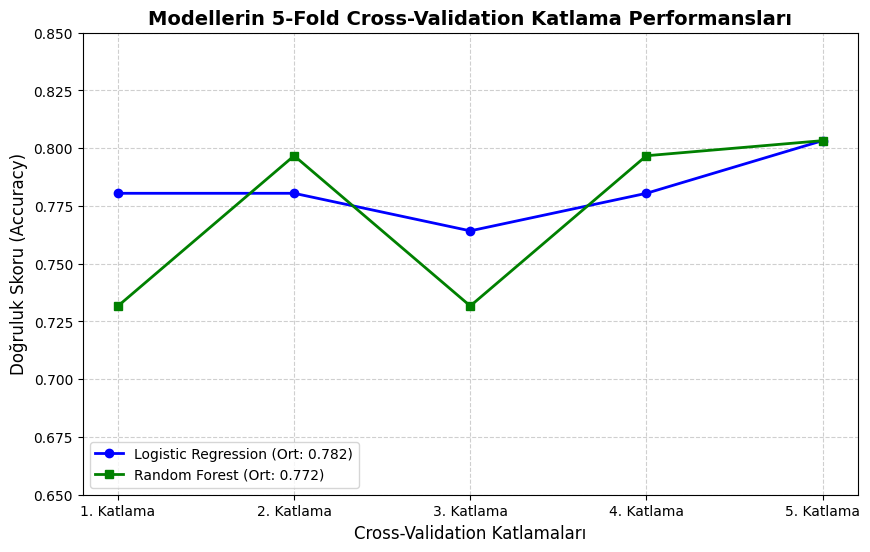

In [10]:
# 1. ADIM: Gerekli kütüphaneleri çağırıyoruz
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# 2. ADIM: Bilgisayara 5-Fold Cross Validation skorlarını hesaplatıyoruz
# Logistic Regression için standartlaştırılmış (scaled) veriyi kullanıyoruz
log_cv_scores_ = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

# Random Forest için normal eğitim verisini kullanıyoruz
rf_cv_scores_ = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')


# 3. ADIM: Hesaplanan bu skorları çizgi grafiğine döküyoruz
folds = ["1. Katlama", "2. Katlama", "3. Katlama", "4. Katlama", "5. Katlama"]

plt.figure(figsize=(10, 6))

# Logistic Regression Çizgisi
plt.plot(folds, log_cv_scores_, marker='o', linewidth=2, color='blue',
         label=f'Logistic Regression (Ort: {log_cv_scores_.mean():.3f})')

# Random Forest Çizgisi
plt.plot(folds, rf_cv_scores_, marker='s', linewidth=2, color='green',
         label=f'Random Forest (Ort: {rf_cv_scores_.mean():.3f})')

# Grafik Tasarımı ve Etiketler
plt.title('Modellerin 5-Fold Cross-Validation Katlama Performansları', fontsize=14, fontweight='bold')
plt.xlabel('Cross-Validation Katlamaları', fontsize=12)
plt.ylabel('Doğruluk Skoru (Accuracy)', fontsize=12)
plt.ylim(0.65, 0.85)  # Grafikteki dalgalanmaları net görebilmek için alt ve üst sınırı sabitledik
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.show()

1. **Genel Tablo / Cross-Validation Özeti:** Modelleri tek bir test verisiyle değil, veri setini 5 farklı parçaya bölerek her seferinde farklı bir parçayı test seti olarak kullanıp 5 kez eğittik. Bu yöntem sonuçların şansa bağlı olup olmadığını ortaya koyar.

2. **Ortalama Başarı Kıyaslaması — ÖNEMLİ ÇELİŞKİ AÇIKLAMASI:** 5-fold CV sonuçlarında Logistic Regression ortalama %78.20, Random Forest ortalama %77.20 çıktı. Bu ilk bakışta şaşırtıcı görünebilir; çünkü tek seferlik testte Random Forest daha yüksek accuracy vermişti. Bunun nedeni şudur: Random Forest küçük veri setlerinde (768 kayıt) bazen aşırı öğrenme (overfitting) eğilimi gösterir. Logistic Regression ise daha sade yapısı sayesinde bazı fold'larda daha tutarlı performans sergiledi. Bu nedenle CV ortalaması tek seferlik test sonucundan daha güvenilir bir ölçüttür.

3. **Potansiyel Overfitting ve Model Seçimi:** Standart sapma incelendiğinde Logistic Regression daha tutarlı (düşük varyans) bir model olduğunu göstermektedir. Random Forest ise bazı fold'larda daha yüksek, bazılarında daha düşük skor verdi. Peki hangi modeli seçmeliyiz? Bu sorunun cevabı kullanım senaryosuna bağlıdır:

* Eğer amaç genel doğruluk ve AUC ise → **Random Forest**
* Eğer amaç tutarlılık, açıklanabilirlik ve küçük veri setinde güvenilirlik ise → **Logistic Regression**

Bu tıbbi projede Recall öncelikli düşünüldüğünde Random Forest öne çıkmaktadır; ancak veri seti büyütüldüğünde bu avantaj daha da netleşecektir.